##### **Import packages and read data**

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Kết nối database
conn = sqlite3.connect('data/oulad.db')

assessment       = pd.read_sql("SELECT * FROM assessments", conn)
courses          = pd.read_sql("SELECT * FROM courses", conn)
student_info     = pd.read_sql("SELECT * FROM studentInfo", conn)
student_regs     = pd.read_sql("SELECT * FROM studentRegistration", conn)
student_assessment = pd.read_sql("SELECT * FROM studentAssessment", conn)
vle              = pd.read_sql("SELECT * FROM vle", conn)

##### **Assessment data info**

In [3]:
assessment = assessment.merge(courses, on=['code_module', 'code_presentation'])
assessment

,code_module,code_presentation,id_assessment,assessment_type,date,weight,module_presentation_length
0,AAA,2013J,1752,TMA,19,10.0,268
1,AAA,2013J,1753,TMA,54,20.0,268
2,AAA,2013J,1754,TMA,117,20.0,268
3,AAA,2013J,1755,TMA,166,20.0,268
4,AAA,2013J,1756,TMA,215,30.0,268
...,...,...,...,...,...,...,...
201,GGG,2014J,37443,CMA,229,0.0,269
202,GGG,2014J,37435,TMA,61,0.0,269
203,GGG,2014J,37436,TMA,124,0.0,269
204,GGG,2014J,37437,TMA,173,0.0,269


In [4]:
assessment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   code_module                 206 non-null    object 
 1   code_presentation           206 non-null    object 
 2   id_assessment               206 non-null    int64  
 3   assessment_type             206 non-null    object 
 4   date                        206 non-null    object 
 5   weight                      206 non-null    float64
 6   module_presentation_length  206 non-null    int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 11.4+ KB


In [5]:
assessment['id_assessment'] = assessment['id_assessment'].astype('object')

**Assessment descriptive statistics**

In [6]:
assessment.describe(include='object').T

,count,unique,top,freq
code_module,206,7,FFF,52
code_presentation,206,4,2014J,57
id_assessment,206,206,1752,1
assessment_type,206,3,TMA,106
date,206,75,222,15


- Dataset gồm 7 module: AAA, BBB, CCC, DDD, EEE, FFF và GGG. Trong đó FFF có nhiều assessment nhất với 52 bài. 

- Về thời điểm học, có 4 presentation: 2013B, 2013J, 2014B và 2014J. `B` tức là module bắt đầu học từ tháng 2, `J` tức là module bắt đầu học từ tháng 10.

- Có 3 loại assessment là: TMA, CMA, Exam. Trong đó TMA chiếm nhiều nhất với 106/206 bài (~51%).

- Có tất cả 206 `id_assessment` đều là duy nhất (unique = 206) → **không có assessment nào bị trùng lặp** trong dataset.

**Modules distribution by bar chart**

Text(0.5, 1.0, 'Distribution of Code Modules')

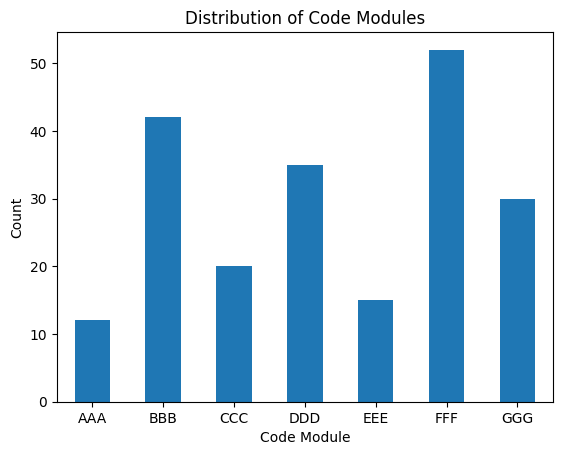

In [7]:
assessment['code_module'].value_counts().sort_index().plot(kind = 'bar', rot = 0)
plt.ylabel('Count')
plt.xlabel('Code Module')
plt.title('Distribution of Code Modules')

**Assessment types percentage by pie chart**

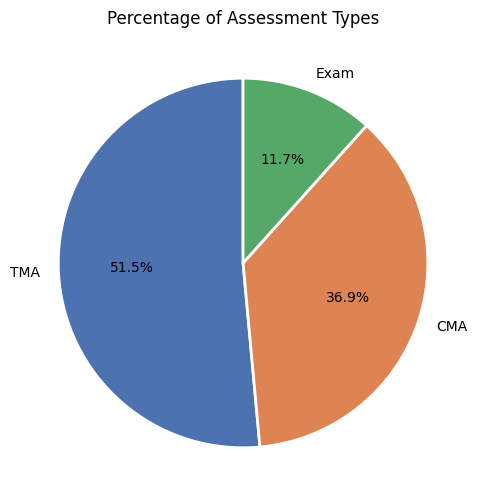

In [8]:
assessment['assessment_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0', '#DD8452', '#55A868'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    title='Percentage of Assessment Types',
    figsize=(6, 6)
)

plt.ylabel('')  # ẩn label 'assessment_type' mặc định ở trục y
plt.show()

**Calculate sum of assessment's weight**

In [9]:
assessment[['code_module','code_presentation','weight']].groupby(['code_module','code_presentation']).sum()

weight
code_module code_presentation        
AAA         2013J               200.0
            2014J               200.0
BBB         2013B               200.0
            2013J               200.0
            2014B               200.0
            2014J               200.0
CCC         2014B               300.0
            2014J               300.0
DDD         2013B               200.0
            2013J               200.0
            2014B               200.0
            2014J               200.0
EEE         2013J               200.0
            2014B               200.0
            2014J               200.0
FFF         2013B               200.0
            2013J               200.0
            2014B               200.0
            2014J               200.0
GGG         2013J               100.0
            2014B               100.0
            2014J               100.0

**Detecting anomaly in GGG and CCC weight**

In [10]:
assessment[assessment['code_module'] == 'GGG'].head()

,code_module,code_presentation,id_assessment,assessment_type,date,weight,module_presentation_length
176,GGG,2013J,37418,CMA,229,0.0,261
177,GGG,2013J,37419,CMA,229,0.0,261
178,GGG,2013J,37420,CMA,229,0.0,261
179,GGG,2013J,37421,CMA,229,0.0,261
180,GGG,2013J,37422,CMA,229,0.0,261


In [11]:
assessment[assessment['code_module'] == 'CCC']

,code_module,code_presentation,id_assessment,assessment_type,date,weight,module_presentation_length
54,CCC,2014B,24286,CMA,18,2.0,241
55,CCC,2014B,24287,CMA,67,7.0,241
56,CCC,2014B,24288,CMA,137,8.0,241
57,CCC,2014B,24289,CMA,207,8.0,241
58,CCC,2014B,24282,TMA,32,9.0,241
59,CCC,2014B,24283,TMA,102,22.0,241
60,CCC,2014B,24284,TMA,151,22.0,241
61,CCC,2014B,24285,TMA,200,22.0,241
62,CCC,2014B,24290,Exam,?,100.0,241
63,CCC,2014B,40087,Exam,?,100.0,241


- Phần lớn modules (AAA, BBB, DDD, EEE, FFF) có tổng weight = 200, mang tính nhất quán.
- Không phải module nào cũng chạy đủ 4 kỳ (`2013B`, `2013J`, `2014B`, `2014J`) — ví dụ AAA chỉ có `2013J` và `2014J`.

**Điểm bất thường:**

- GGG có tổng weight = 100: tất cả TMA và CMA của GGG đều có `weight = 0.0`, chỉ Exam mới có `weight = 100.0`, nói cách khác, kết quả module phụ thuộc hoàn toàn vào bài kiểm tra cuối kì.

- CCC có tổng weight = 300: module CCC có 2 Exam trong mỗi presentation (mỗi cái `weight = 100`), cộng với TMA+CMA = 100 → tổng = 300.

- Ở module CCC, cột `date` tồn tại giá trị '?' trong các bản ghi có `assignment_types = 'Exam'`

**Checking missing values in `date` column**

In [12]:
assessment[assessment.date == '?']

,code_module,code_presentation,id_assessment,assessment_type,date,weight,module_presentation_length
5,AAA,2013J,1757,Exam,?,100.0,268
11,AAA,2014J,1763,Exam,?,100.0,269
23,BBB,2013B,14990,Exam,?,100.0,240
35,BBB,2013J,15002,Exam,?,100.0,268
47,BBB,2014B,15014,Exam,?,100.0,234
53,BBB,2014J,15025,Exam,?,100.0,262
62,CCC,2014B,24290,Exam,?,100.0,241
63,CCC,2014B,40087,Exam,?,100.0,241
72,CCC,2014J,24299,Exam,?,100.0,269
73,CCC,2014J,40088,Exam,?,100.0,269


- `date = '?'` chỉ xuất hiện ở loại `Exam`, không có ở TMA hay CMA → missing có tính hệ thống, không phải ngẫu nhiên.
- 11/24 exam rows bị thiếu ngày, chiếm gần một nửa (~45.8%).
- Mức độ thiếu theo module:
  - AAA, BBB, CCC: thiếu hoàn toàn — không có presentation nào có ngày thi chính xác.
  - DDD: chỉ thiếu 1 presentation (2014J), 3 presentation còn lại có đầy đủ.
  - EEE, FFF, GGG: đầy đủ ngày thi cho tất cả presentations.
- Khả năng cao các module bị thiếu có lịch thi linh hoạt nên không có ngày cố định trong hệ thống.
- Vì Exam thường ở cuối khoá học (ngoài window dự báo), ảnh hưởng thực tế của missing này là **không đáng kể**.


**Student info**

In [13]:
# student_df = (
#     student_info
#     .merge(student_regs, on=['id_student', 'code_module', 'code_presentation'])
#     .merge(student_assessment, on='id_student', how='left') 
# )
# student_df

**VLE data extraction**

In [14]:
vle_weekly = pd.read_sql("""
    SELECT 
        sv.id_student,
        sv.code_module,
        sv.code_presentation,
        v.activity_type,
        CAST(FLOOR(CAST(sv.date AS FLOAT) / 7) AS INTEGER) AS week,
        SUM(sv.sum_click) AS weekly_clicks
    FROM studentVle sv
    JOIN vle v 
        ON sv.id_site = v.id_site
        AND sv.code_module = v.code_module
        AND sv.code_presentation = v.code_presentation
    GROUP BY sv.id_student, sv.code_module, sv.code_presentation, v.activity_type, week
""", conn)

In [34]:
vle_weekly.sort_values(['id_student', 'code_module', 'code_presentation', 'week', 'activity_type'], inplace=True)
vle_weekly

,id_student,code_module,code_presentation,activity_type,week,weekly_clicks
4,6516,AAA,2014J,forumng,-4,33
37,6516,AAA,2014J,homepage,-4,16
76,6516,AAA,2014J,oucontent,-4,57
106,6516,AAA,2014J,resource,-4,2
118,6516,AAA,2014J,subpage,-4,2
...,...,...,...,...,...,...
2518135,2698588,BBB,2014J,oucontent,34,1
2518095,2698588,BBB,2014J,forumng,35,1
2518118,2698588,BBB,2014J,homepage,35,2
2518136,2698588,BBB,2014J,oucontent,35,4


In [42]:
vle_weekly_agg = (
    vle_weekly
    .groupby(['id_student', 'code_module', 'code_presentation', 'week'], as_index=False)
    .agg(weekly_clicks=('weekly_clicks', 'sum'))
)
vle_weekly_agg


,id_student,code_module,code_presentation,week,weekly_clicks
0,6516,AAA,2014J,-4,110
1,6516,AAA,2014J,-3,48
2,6516,AAA,2014J,-2,2
3,6516,AAA,2014J,-1,96
4,6516,AAA,2014J,0,229
...,...,...,...,...,...
627026,2698588,BBB,2014J,32,13
627027,2698588,BBB,2014J,33,147
627028,2698588,BBB,2014J,34,12
627029,2698588,BBB,2014J,35,7


In [46]:
vle_weekly_agg.describe().apply(lambda x: x.apply('{:.2f}'.format))

,id_student,week,weekly_clicks
count,627031.00,627031.00,627031.00
mean,716245.32,14.06,63.16
std,563638.18,11.02,96.59
min,6516.00,-4.00,1.00
25%,505773.00,4.00,9.00
50%,589295.00,13.00,30.00
75%,645183.00,23.00,78.00
max,2698588.00,38.00,6999.00


- `vle_weekly_agg` gồm **627,031** bản ghi — sau khi gộp `activity_type`, số dòng giảm ~4 lần so với `vle_weekly` (2,518,170), mỗi bản ghi là tổng click của 1 sinh viên trong 1 tuần.

- Cột `week`:
    - Tuần được tính bằng `floor(date / 7)`, tính từ ngày bắt đầu module.
    - Giá trị âm (`min = -4`) cho thấy một số sinh viên đã truy cập VLE trước khi khoá học chính thức bắt đầu.
    - 50% bản ghi nằm trong tuần 4–23, tương ứng giai đoạn giữa khoá học.
    - `max = 38` (~9.5 tháng) phù hợp với độ dài các module trong OULAD (~240–270 ngày).

- Cột `weekly_clicks`:
    - Phân phối lệch phải nặng: median = 30 nhưng mean = 63.16 chứng tỏ dữ liệu bị kéo lên bởi outliers. Trong đó có các outlier cực đoan ví dụ như `max = 6,999` trong khi Q3 = 78.
    - `std = 96.59 > mean = 63.16` cho thấy độ phân tán rất lớn.


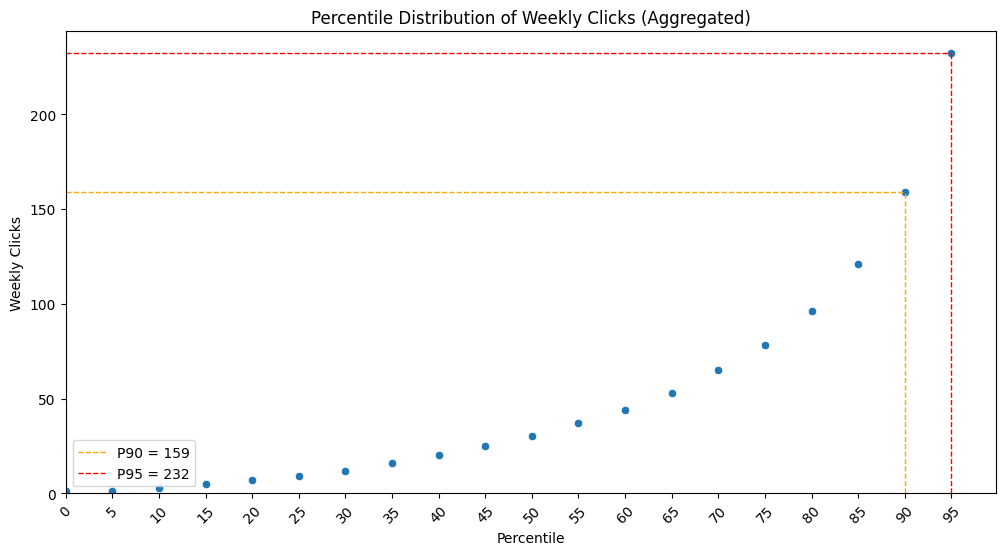

In [58]:
percentiles = range(0, 100, 5)
values = [vle_weekly_agg['weekly_clicks'].quantile(p / 100) for p in percentiles]

p90 = vle_weekly_agg['weekly_clicks'].quantile(0.90)
p95 = vle_weekly_agg['weekly_clicks'].quantile(0.95)

plt.figure(figsize=(12, 6))
sns.scatterplot(x=list(percentiles), y=values)

plt.plot([90, 90], [0, p90], color='orange', linestyle='--', linewidth=1)
plt.plot([0, 90],  [p90, p90], color='orange', linestyle='--', linewidth=1, label=f'P90 = {p90:.0f}')

plt.plot([95, 95], [0, p95], color='red', linestyle='--', linewidth=1)
plt.plot([0, 95],  [p95, p95], color='red', linestyle='--', linewidth=1, label=f'P95 = {p95:.0f}')

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.title('Percentile Distribution of Weekly Clicks (Aggregated)')
plt.xlabel('Percentile')
plt.xticks(range(0, 100, 5), rotation=45)
plt.ylabel('Weekly Clicks')
plt.legend()
plt.show()


- Từ P0 đến P75, weekly_clicks tăng chậm từ 1 đến 80 — phần lớn sinh viên tương tác ở mức vừa phải mỗi tuần.
- Từ P75 trở đi đường cong dốc lên nhanh, dấu hiệu của phân phối lệch phải với đuôi dài.
- P90 = 159, P95 = 232 — 10% sinh viên tích cực nhất có lượng click gấp ~2.5 lần mức trung bình (mean = 63.16).


**Check number of students remaining after every month**

In [61]:
def build_snapshot_dataset():
    PREDICTION_POINTS = [30, 60, 90, 120, 150, 180, 210, 240]
    # --- Chuẩn bị student_assessment_joined TRƯỚC loop ---
    student_assessment_joined = pd.read_sql("""
        SELECT
            sa.id_student,
            sa.id_assessment,
            sa.date_submitted,
            sa.is_banked,
            sa.score,
            a.code_module,
            a.code_presentation,
            a.assessment_type,
            a.date   AS deadline_raw,
            a.weight
        FROM studentAssessment sa
        JOIN assessments a ON sa.id_assessment = a.id_assessment
    """, conn)

    student_assessment_joined['deadline'] = pd.to_numeric(
        student_assessment_joined['deadline_raw'], errors='coerce'
    ).astype('float')

    student_assessment_joined['score'] = pd.to_numeric(
        student_assessment_joined['score'], errors='coerce'
    ).astype('float')

    student_assessment_joined['days_early'] = (
        student_assessment_joined['deadline'] - student_assessment_joined['date_submitted']
    )

    student_assessment_joined['is_failed'] = (
        student_assessment_joined['score'] < 40
    ).astype(int)
    student_assessment_joined['weighted_score'] = (
        student_assessment_joined['score'] * student_assessment_joined['weight'] / 100
    )

    student_assessment_joined.drop(columns='deadline_raw', inplace=True)

    # Convert date_unregistration sang float để so sánh với T
    student_regs['date_unregistration'] = pd.to_numeric(
        student_regs['date_unregistration'], errors='coerce'
    ).astype('float')

    frames = []


    # --- Loop ---
    for T in PREDICTION_POINTS:

        # --- Chỉ giữ sinh viên còn active tại thời điểm T ---
        active_students = student_regs[
            (student_regs['date_unregistration'].isna()) |
            (student_regs['date_unregistration'] > T)
        ]
        # VLE features
        vle_feat = (
            vle_weekly_agg[vle_weekly_agg['week'] <= T // 7]
            .groupby(['id_student', 'code_module', 'code_presentation'])
            .agg(
                total_clicks      = ('weekly_clicks', 'sum'),
                active_weeks      = ('week', 'nunique'),
            )
            .reset_index()
        )
        vle_feat['avg_weekly_clicks'] = vle_feat['total_clicks'] / vle_feat['active_weeks']
        
        # Assessment features
        # Bài phải thi tính đến T (theo lịch module, không phụ thuộc sinh viên)
        num_due_per_module = assessment.copy()
        num_due_per_module['date_num'] = pd.to_numeric(num_due_per_module['date'], errors='coerce')
        num_due_per_module = (
            num_due_per_module[num_due_per_module['date_num'] <= T]
            .groupby(['code_module', 'code_presentation'])
            .agg(num_due=('id_assessment', 'count'))
            .reset_index()
        )

        # Chỉ lấy bài có deadline <= T VÀ đã nộp trước T (tránh data leakage)
        submitted_in_window = student_assessment_joined[
            (student_assessment_joined['deadline'] <= T) &
            (student_assessment_joined['date_submitted'] <= T)
        ]
        assess_feat = (
            submitted_in_window
            .groupby(['id_student', 'code_module', 'code_presentation'])
            .agg(
                num_submitted  = ('id_assessment', 'count'),
                total_w_score  = ('weighted_score', 'sum'),  # Σ(score × weight / 100)
                total_weight   = ('weight', 'sum'),           # Σ weight
                avg_days_early = ('days_early', 'mean'),
                num_failed     = ('is_failed', 'sum'),
            )
            .reset_index()
        )

        # Weighted average score = Σ(score × weight) / Σ(weight)
        assess_feat['avg_score'] = (
            assess_feat['total_w_score'] * 100 / assess_feat['total_weight'].replace(0, pd.NA)
        )
        assess_feat['avg_score'] = pd.to_numeric(assess_feat['avg_score'], errors='coerce').round(2)
        assess_feat['avg_days_early'] = assess_feat['avg_days_early'].round(2)

        assess_feat.drop(columns=['total_w_score', 'total_weight'], inplace=True)

        # Gắn num_due và tính submission_rate
        assess_feat = assess_feat.merge(
            num_due_per_module, on=['code_module', 'code_presentation'], how='left'
        )
        assess_feat['submission_rate'] = assess_feat['num_submitted'] / assess_feat['num_due']
      
        # Static features + label — chỉ lấy sinh viên còn active
        static = student_info[[
            'id_student', 'code_module', 'code_presentation',
            'gender', 'region', 'highest_education', 'imd_band',
            'age_band', 'num_of_prev_attempts', 'studied_credits',
            'disability', 'final_result'
        ]].merge(
            active_students,
            on=['id_student', 'code_module', 'code_presentation'],
            how='inner'
        )
        
        # Merge
        df_T = (
            static
            .merge(vle_feat,    on=['id_student', 'code_module', 'code_presentation'], how='left')
            .merge(assess_feat, on=['id_student', 'code_module', 'code_presentation'], how='left')
        )
        df_T['prediction_point'] = T
        frames.append(df_T)
        # print(f"T={T} days → {len(df_T):,} students remaining")
        # display(df_T.head())
    df_all = pd.concat(frames, ignore_index=True)
    return df_all



Hàm `build_snapshot_dataset()` nhằm xây dựng dataset dạng panel cho bài toán dự báo rủi ro học tập sớm. Với mỗi mốc thời gian `T` trong `[30, 60, 90, 120, 150, 180, 210, 240]` ngày, hàm tạo một snapshot thể hiện trạng thái của từng sinh viên tại thời điểm đó.

- **Chuẩn bị (trước loop)**
  - Join `studentAssessment` với `assessments` để lấy deadline, weight, loại bài thi.
  - Tính các cột phái sinh:
    - `days_early`: số ngày nộp sớm (âm = nộp trễ).
    - `is_failed`: 1 nếu điểm < 40, ngược lại 0.
    - `weighted_score`: điểm có trọng số = `score × weight / 100`.
    - Chuyển `date_unregistration` sang số để so sánh với `T`.

- **Trong mỗi vòng lặp tại T**
  - Lọc sinh viên còn active: loại những sinh viên đã rút khỏi khoá trước ngày `T`.
  - VLE features (chỉ lấy dữ liệu đến tuần `T // 7`):
    - `total_clicks`: tổng số click tích luỹ đến T.
    - `active_weeks`: số tuần có tương tác.
    - `avg_weekly_clicks`: click trung bình mỗi tuần.
  - Assessment features (chỉ lấy bài có deadline ≤ T và đã nộp trước T — tránh data leakage):
    - `num_submitted`: số bài đã nộp.
    - `avg_score`: điểm trung bình có trọng số.
    - `avg_days_early`: độ trễ/sớm nộp bài trung bình.
    - `num_failed`: số bài bị trượt (< 40 điểm).
    - `num_due`: số bài đến hạn tính đến T (theo lịch module).
    - `submission_rate`: tỉ lệ nộp bài = `num_submitted / num_due`.
  - Static features: thông tin cá nhân sinh viên (giới tính, vùng, trình độ học vấn, `imd_band`...) và nhãn `final_result`.
  - Merge tất cả lại, gắn biến chỉ mốc thời gian dự đoán `prediction_point = T`.

- **Đầu ra**
  - DataFrame `df_all` gồm 8 snapshot ghép lại — mỗi sinh viên xuất hiện tối đa 8 lần (một lần cho mỗi mốc T còn active), sẵn sàng cho bước huấn luyện model.


In [62]:
final_df = build_snapshot_dataset()
final_df = final_df[[c for c in final_df.columns if c != 'final_result'] + ['final_result']]
final_df

,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,active_weeks,avg_weekly_clicks,num_submitted,avg_days_early,num_failed,avg_score,num_due,submission_rate,prediction_point,final_result
0,11391,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,5.0,85.400000,1.0,1.00,0.0,78.0,1.0,1.0,30,Pass
1,28400,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,7.0,89.285714,1.0,-3.00,0.0,70.0,1.0,1.0,30,Pass
2,31604,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,7.0,80.857143,1.0,2.00,0.0,72.0,1.0,1.0,30,Pass
3,32885,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,7.0,83.571429,1.0,-7.00,0.0,69.0,1.0,1.0,30,Pass
4,38053,AAA,2013J,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,...,7.0,109.142857,1.0,0.00,0.0,79.0,1.0,1.0,30,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196927,2620947,GGG,2014J,F,Scotland,A Level or Equivalent,80-90%,0-35,0,30,...,20.0,23.750000,9.0,31.44,0.0,NaN,10.0,0.9,240,Distinction
196928,2640965,GGG,2014J,F,Wales,Lower Than A Level,10-20,0-35,0,30,...,4.0,10.250000,NaN,NaN,NaN,NaN,NaN,NaN,240,Fail
196929,2645731,GGG,2014J,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,...,25.0,35.680000,9.0,36.22,0.0,NaN,10.0,0.9,240,Distinction
196930,2648187,GGG,2014J,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,...,19.0,16.421053,9.0,45.33,0.0,NaN,10.0,0.9,240,Pass


In [21]:
display(final_df.info())
final_df['final_result'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196932 entries, 0 to 196931
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id_student            196932 non-null  int64  
 1   code_module           196932 non-null  object 
 2   code_presentation     196932 non-null  object 
 3   gender                196932 non-null  object 
 4   region                196932 non-null  object 
 5   highest_education     196932 non-null  object 
 6   imd_band              196932 non-null  object 
 7   age_band              196932 non-null  object 
 8   num_of_prev_attempts  196932 non-null  int64  
 9   studied_credits       196932 non-null  int64  
 10  disability            196932 non-null  object 
 11  date_registration     196932 non-null  object 
 12  date_unregistration   16764 non-null   float64
 13  total_clicks          192993 non-null  float64
 14  active_weeks          192993 non-null  float64
 15  

None

final_result
Pass           98888
Fail           56349
Distinction    24192
Withdrawn      17503
Name: count, dtype: int64

In [22]:
# n_student = final_df['id_student'].nunique()
# for point in range(30, 241, 30):
#     count = final_df[final_df.prediction_point == point]['id_student'].nunique()
#     print(f"At T={point} days: {count} unique students")
#     print(f"  → Lost {n_student - count} students compared to previous point")
#     n_student = count


In [23]:
def remove_columns(df):
    new_df = df.copy()
    new_df = new_df.drop(columns=['id_student', 'code_module', 'code_presentation', 'date_registration',
                                  'date_unregistration', 'prediction_point', 'final_result'])
    return new_df

remove_columns(final_df)

,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,total_clicks,active_weeks,avg_weekly_clicks,num_submitted,avg_days_early,num_failed,avg_score,num_due,submission_rate
0,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,427.0,5.0,85.400000,1.0,1.00,0.0,78.0,1.0,1.0
1,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,625.0,7.0,89.285714,1.0,-3.00,0.0,70.0,1.0,1.0
2,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,566.0,7.0,80.857143,1.0,2.00,0.0,72.0,1.0,1.0
3,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,585.0,7.0,83.571429,1.0,-7.00,0.0,69.0,1.0,1.0
4,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,764.0,7.0,109.142857,1.0,0.00,0.0,79.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196927,F,Scotland,A Level or Equivalent,80-90%,0-35,0,30,Y,475.0,20.0,23.750000,9.0,31.44,0.0,NaN,10.0,0.9
196928,F,Wales,Lower Than A Level,10-20,0-35,0,30,N,41.0,4.0,10.250000,NaN,NaN,NaN,NaN,NaN,NaN
196929,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,N,892.0,25.0,35.680000,9.0,36.22,0.0,NaN,10.0,0.9
196930,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,Y,312.0,19.0,16.421053,9.0,45.33,0.0,NaN,10.0,0.9


**Question marks in columns**

In [63]:
# Tìm các cột có chứa dấu '?'
cols_with_question = [col for col in final_df.columns if (final_df[col] == '?').any()]

print(f"Số cột có dấu '?': {len(cols_with_question)}")
print(f"Các cột có dấu '?': {cols_with_question}")

Số cột có dấu '?': 2
Các cột có dấu '?': ['imd_band', 'date_registration']


In [64]:
print(f"Số lượng missing value ở cột imd_band: {len(final_df[final_df['imd_band'] == '?'])}")
print(f"Tỉ lệ missing value ở cột imd_band: {len(final_df[final_df['imd_band'] == '?']) / len(final_df) * 100:.2f}%")

Số lượng missing value ở cột imd_band: 7539
Tỉ lệ missing value ở cột imd_band: 3.83%


In [65]:
# Tỷ lệ % region theo từng imd_band + count
result = (
    final_df.groupby(['imd_band', 'region'])
    .size()
    .reset_index(name='count')
)

result['percent'] = (
    result.groupby('imd_band')['count']
    .transform(lambda x: x / x.sum() * 100)
    .round(2)
)

print(result[result['imd_band'] == '?'].sort_values('count', ascending=False).to_string(index=False))

imd_band               region  count  percent
       ?         North Region   4952    65.69
       ?              Ireland   1830    24.27
       ?         South Region    340     4.51
       ? West Midlands Region    279     3.70
       ?             Scotland     68     0.90
       ?    South West Region     32     0.42
       ? North Western Region     24     0.32
       ?     Yorkshire Region     14     0.19


In [27]:
imd_by_region = (
    pd.crosstab(final_df['region'], final_df['imd_band'], normalize='index') * 100
).round(2)

imd_by_region = imd_by_region.sort_values('?', ascending=False)

display(
    imd_by_region.style
    .format("{:.2f}%")
    .background_gradient(cmap='YlOrRd', axis=1)
    .set_caption("Phân phối imd_band (%) theo Region")
    .set_table_styles([
        {'selector': 'caption',  'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'table',    'props': [('border-collapse', 'collapse'), ('width', '100%'), ('font-size', '14px')]},
        {'selector': 'th, td',   'props': [('padding', '8px 14px'), ('text-align', 'center')]},
        {'selector': '',         'props': [('overflow-y', 'auto'), ('max-height', '500px'), ('display', 'block')]},
    ])
)


imd_band,0-10%,10-20,20-30%,30-40%,40-50%,50-60%,60-70%,70-80%,80-90%,90-100%,?
region,,,,,,,,,,,
North Region,8.08%,10.82%,7.07%,6.48%,5.79%,3.72%,3.80%,4.37%,4.22%,0.47%,45.19%
Ireland,9.94%,9.79%,6.98%,7.91%,5.98%,9.11%,7.08%,7.42%,6.78%,5.96%,23.03%
West Midlands Region,18.24%,13.50%,11.30%,9.99%,9.94%,7.31%,8.74%,8.88%,5.35%,4.87%,1.89%
South Region,0.89%,4.61%,6.02%,6.69%,10.54%,10.31%,8.59%,12.75%,15.25%,22.56%,1.79%
Scotland,7.77%,7.79%,10.38%,11.09%,10.21%,11.73%,10.79%,10.16%,10.27%,9.51%,0.30%
South West Region,3.98%,7.13%,10.53%,16.41%,11.87%,12.34%,11.42%,11.28%,8.32%,6.50%,0.22%
North Western Region,24.37%,12.64%,13.51%,10.85%,8.13%,8.87%,6.20%,6.71%,5.40%,3.17%,0.14%
Yorkshire Region,17.56%,13.22%,12.14%,11.32%,9.90%,9.83%,7.90%,9.23%,5.80%,2.97%,0.12%
East Anglian Region,3.02%,4.66%,8.71%,10.60%,11.71%,11.26%,12.45%,12.54%,12.01%,13.04%,0.00%


In [28]:
imd_by_edu = (
    pd.crosstab(final_df['highest_education'], final_df['imd_band'], normalize='index') * 100
).round(2)

imd_order = ['0-10%', '10-20', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%', '?']

edu_order = [
    'No Formal quals',
    'Lower Than A Level',
    'A Level or Equivalent',
    'HE Qualification',
    'Post Graduate Qualification'
]

imd_by_edu = imd_by_edu.reindex(edu_order).reindex(columns=imd_order)

display(
    imd_by_edu.style
    .format("{:.2f}%")
    .background_gradient(cmap='YlOrRd', axis=1)
    .set_caption("Phân phối IMD Band (%) theo Highest Education")
    .set_table_styles([
        {'selector': 'caption',  'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'table',    'props': [('border-collapse', 'collapse'), ('width', '100%'), ('font-size', '14px')]},
        {'selector': 'th, td',   'props': [('padding', '8px 14px'), ('text-align', 'center')]},
        {'selector': '',         'props': [('overflow-y', 'auto'), ('max-height', '500px'), ('display', 'block')]},
    ])
)

imd_band,0-10%,10-20,20-30%,30-40%,40-50%,50-60%,60-70%,70-80%,80-90%,90-100%,?
highest_education,,,,,,,,,,,
No Formal quals,18.56%,17.66%,22.55%,17.21%,1.46%,6.75%,4.39%,1.52%,0.00%,2.25%,7.65%
Lower Than A Level,11.67%,11.69%,11.44%,10.76%,9.69%,9.88%,8.82%,8.69%,7.72%,6.25%,3.39%
A Level or Equivalent,8.61%,10.01%,9.92%,11.25%,10.39%,10.24%,9.65%,9.70%,9.17%,8.72%,2.33%
HE Qualification,6.36%,6.90%,10.22%,10.37%,9.61%,9.05%,8.85%,10.12%,10.88%,11.13%,6.52%
Post Graduate Qualification,0.00%,4.55%,5.31%,1.48%,1.82%,4.88%,6.08%,1.53%,8.28%,25.89%,40.19%


In [29]:
import numpy as np

np.random.seed(42)

def fill_imd_by_distribution(df):
    df = df.copy()
    
    before = df['imd_band'].value_counts()
    
    for region, group in df[df['imd_band'] != '?'].groupby('region'):
        dist = group['imd_band'].value_counts(normalize=True)
        mask = (df['region'] == region) & (df['imd_band'] == '?')
        n = mask.sum()
        
        if n > 0:
            df.loc[mask, 'imd_band'] = np.random.choice(
                dist.index,
                size=n,
                p=dist.values
            )
    
    after = df['imd_band'].value_counts()
    
    compare = pd.DataFrame({
        'before': before,
        'after' : after
    }).fillna(0).astype(int)
    compare['delta'] = compare['after'] - compare['before']
    compare = compare.sort_index()
    
    #print(compare.to_string())
    return df
    

fill_imd_by_distribution(final_df)

,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,active_weeks,avg_weekly_clicks,num_submitted,avg_days_early,num_failed,avg_score,num_due,submission_rate,prediction_point,final_result
0,11391,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,5.0,85.400000,1.0,1.00,0.0,78.0,1.0,1.0,30,Pass
1,28400,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,7.0,89.285714,1.0,-3.00,0.0,70.0,1.0,1.0,30,Pass
2,31604,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,7.0,80.857143,1.0,2.00,0.0,72.0,1.0,1.0,30,Pass
3,32885,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,7.0,83.571429,1.0,-7.00,0.0,69.0,1.0,1.0,30,Pass
4,38053,AAA,2013J,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,...,7.0,109.142857,1.0,0.00,0.0,79.0,1.0,1.0,30,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196927,2620947,GGG,2014J,F,Scotland,A Level or Equivalent,80-90%,0-35,0,30,...,20.0,23.750000,9.0,31.44,0.0,NaN,10.0,0.9,240,Distinction
196928,2640965,GGG,2014J,F,Wales,Lower Than A Level,10-20,0-35,0,30,...,4.0,10.250000,NaN,NaN,NaN,NaN,NaN,NaN,240,Fail
196929,2645731,GGG,2014J,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,...,25.0,35.680000,9.0,36.22,0.0,NaN,10.0,0.9,240,Distinction
196930,2648187,GGG,2014J,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,...,19.0,16.421053,9.0,45.33,0.0,NaN,10.0,0.9,240,Pass


In [30]:
def fill_in_weekly_clicks(df):
    df = df.copy()
    df[['total_clicks', 'active_weeks', 'avg_weekly_clicks']] = (
        df[['total_clicks', 'active_weeks', 'avg_weekly_clicks']].fillna(0)
    )
    return df

def fill_in_assessment(df):
    df = df.copy()

    # 1. num_submitted, num_failed, submission_rate → fill 0
    #    Sinh viên chưa nộp bài nào: 0 là giá trị đúng về ngữ nghĩa
    df['num_submitted']   = df['num_submitted'].fillna(0)
    df['num_failed']      = df['num_failed'].fillna(0)
    df['submission_rate'] = df['submission_rate'].fillna(0)

    # 2. num_due → tính lại từ bảng assessment theo từng module + T
    #    Không fill 0 vì num_due là thực tế của module, không phụ thuộc sinh viên có nộp hay không
    assessment_copy = assessment.copy()
    assessment_copy['date_num'] = pd.to_numeric(assessment_copy['date'], errors='coerce')

    num_due_frames = []
    for T in df['prediction_point'].unique():
        tmp = (
            assessment_copy[assessment_copy['date_num'] <= T]
            .groupby(['code_module', 'code_presentation'])
            .size()
            .reset_index(name='_num_due')
        )
        tmp['prediction_point'] = T
        num_due_frames.append(tmp)

    num_due_lookup = pd.concat(num_due_frames, ignore_index=True)
    df = df.merge(num_due_lookup, on=['code_module', 'code_presentation', 'prediction_point'], how='left')
    df['num_due'] = df['num_due'].fillna(df['_num_due'])
    df = df.drop(columns='_num_due')

    # 3. avg_days_early → fill bằng median theo code_module + prediction_point
    #    Không fill 0 vì 0 có nghĩa "nộp đúng deadline", khác với "chưa nộp bài"
    median_days = df.groupby(['code_module', 'prediction_point'])['avg_days_early'].transform('median')
    df['avg_days_early'] = df['avg_days_early'].fillna(median_days)

    return df



In [31]:
processed_df = fill_imd_by_distribution(final_df)
processed_df = fill_in_weekly_clicks(processed_df)
processed_df = fill_in_assessment(processed_df)
processed_df = remove_columns(processed_df)

In [32]:
processed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196932 entries, 0 to 196931
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   gender                196932 non-null  object 
 1   region                196932 non-null  object 
 2   highest_education     196932 non-null  object 
 3   imd_band              196932 non-null  object 
 4   age_band              196932 non-null  object 
 5   num_of_prev_attempts  196932 non-null  int64  
 6   studied_credits       196932 non-null  int64  
 7   disability            196932 non-null  object 
 8   total_clicks          196932 non-null  float64
 9   active_weeks          196932 non-null  float64
 10  avg_weekly_clicks     196932 non-null  float64
 11  num_submitted         196932 non-null  float64
 12  avg_days_early        189542 non-null  float64
 13  num_failed            196932 non-null  float64
 14  avg_score             162200 non-null  float64
 15  

In [33]:
processed_df[processed_df['num_due'].isna()][['num_due','avg_days_early']]

,num_due,avg_days_early
15902,NaN,NaN
15903,NaN,NaN
15904,NaN,NaN
15905,NaN,NaN
15906,NaN,NaN
...,...,...
53822,NaN,NaN
53823,NaN,NaN
53824,NaN,NaN
53825,NaN,NaN
